# 04b – Exploration des unités urbaines (INSEE 2017)
 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

**Plan** : Importation → Contrôle → Nettoyage → Inspection → Visualisation

### Unité urbaine: zone où les bâtiments sont à moins de 200 mètres les uns des autres et qui compte au moins 2 000 habitants.

### Importation des données

In [8]:
uu = pd.read_excel(
    '../data/raw/Socio Eco/insee_unites_urbaines_2017.xlsx',
    sheet_name='Figure 2',      # onglet avec les départements
    header=None,                # pas de ligne de noms de colonnes
    skiprows=2,                 # saute les 2 premières lignes (commentaires)
    names=['code_dep', 'nom_dep', 'pct_urbain'],   # renomme les colonnes
    usecols='A:C',              # sélection des colonnes A-C
    dtype={'code_dep': str}     # code département lu comme du texte 
)

print(uu.shape)
uu.head()

(104, 3)


,code_dep,nom_dep,pct_urbain
0,01,Ain,67.0
1,02,Aisne,53.2
2,03,Allier,58.3
3,04,Alpes-de-Haute-Provence,61.9
4,05,Hautes-Alpes,59.5


### Contrôle des données

In [9]:
uu.tail(8) 

,code_dep,nom_dep,pct_urbain
96,971,Guadeloupe,96.4
97,972,Martinique,96.6
98,973,Guyane,86.3
99,974,La Réunion,98.5
100,976,Mayotte,100.0
101,"Lecture : en 2017, dans l’Ain, 67 % des habita...",NaN,NaN
102,Champ : France.,NaN,NaN
103,"Source : Insee, recensement de la population 2...",NaN,NaN


### Nettoyage des données

In [10]:
# Supprimer les 3 dernières lignes(commentaires)
uu = uu[uu['nom_dep'].notna()]

# Ajouter une colonne pour repérer les DROM (code 97)
uu['est_drom'] = uu['code_dep'].str.startswith('97')

# Actualiser index
uu = uu.reset_index(drop=True)

# Vérifier le résultat
print(uu.shape)
print(uu['est_drom'].value_counts())

(101, 4)
est_drom
False    96
True      5
Name: count, dtype: int64


### Inspection

In [11]:
# Types des colonnes
print(uu.dtypes)

# Pourcentages de valeurs manquantes 
print(uu.isna().mean() * 100)

# Vérification de la cohérence des pourcentages(valeurs 0-100)
print("Min :", uu['pct_urbain'].min(), "/ Max :", uu['pct_urbain'].max())

# Stats descriptives
uu['pct_urbain'].describe()

code_dep          str
nom_dep           str
pct_urbain    float64
est_drom         bool
dtype: object
code_dep      0.0
nom_dep       0.0
pct_urbain    0.0
est_drom      0.0
dtype: float64
Min : 21.4 / Max : 100.0


count    101.000000
mean      69.430693
std       18.225772
min       21.400000
25%       56.800000
50%       67.700000
75%       82.900000
max      100.000000
Name: pct_urbain, dtype: float64

Les variables sont du bon type, aucune n'est manquante. Les pourcentages (21,4-100%) sont cohérents. La moyenne et la médiane sont proches il n' y pas de valeurs extrêmes comme pour certaines catégories socio-professionelles (ex:cadre).
La part urbaine varie beaucoup selon les départements (écart-type de 18)= département rural ou urbain.

### Visualisation

L'histogramme permet d'avoir une idée de la répartition urbaine/rurale des départements.

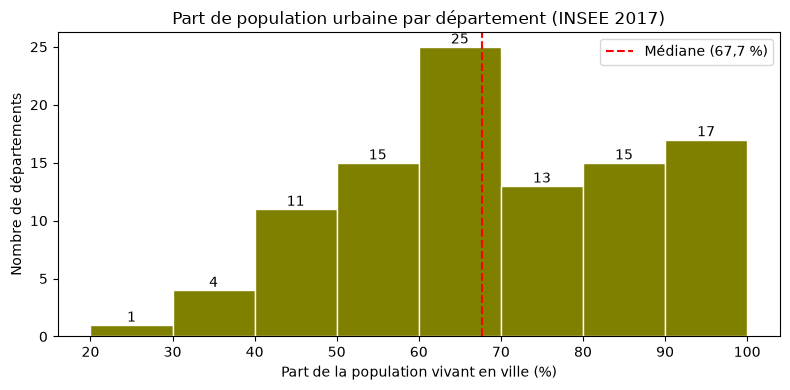

In [12]:
# Histogramme (tranches de 10 %)
fig, ax = plt.subplots(figsize=(8, 4))
tranches = range(20, 101, 10)
barres = ax.hist(uu['pct_urbain'], bins=tranches, color='olive', edgecolor='white')

# Afficher le nombre de départements au-dessus de chaque barre
ax.bar_label(barres[2])

# Ajout de la médiane
ax.axvline(uu['pct_urbain'].median(), color='red', linestyle='--', label='Médiane (67,7 %)')

# Titres, légende 
ax.set_xticks(tranches)
ax.set_xlabel('Part de la population vivant en ville (%)')
ax.set_ylabel('Nombre de départements')
ax.set_title('Part de population urbaine par département (INSEE 2017)')
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Les départements les plus urbains
print(uu.nlargest(10, 'pct_urbain')[['nom_dep', 'pct_urbain']])

# Les départements les plus ruraux
print(uu.nsmallest(10, 'pct_urbain')[['nom_dep', 'pct_urbain']])

               nom_dep  pct_urbain
75               Paris       100.0
92      Hauts-de-Seine       100.0
93   Seine-Saint-Denis       100.0
94        Val-de-Marne       100.0
100            Mayotte       100.0
12    Bouches-du-Rhône        99.3
99          La Réunion        98.5
97          Martinique        96.6
96          Guadeloupe        96.4
91             Essonne        96.1
        nom_dep  pct_urbain
23       Creuse        21.4
14       Cantal        35.3
32         Gers        36.1
48       Lozère        37.0
46          Lot        39.5
55        Meuse        41.2
61         Orne        41.8
70  Haute-Saône        42.6
89        Yonne        43.1
52  Haute-Marne        44.9


- La majorité des départements sont mixtes (40 départements entre 50 et 70 %), ou très urbain (17 départements au-dessus de 90 %) : Île-de-France, DROM, Bouches-du-Rhône.
- Cette variable mesure la densité de population: pertinente pour les maladies contagieuses (bronchiolite), mais ne reflète pas directement la pollution.
- Mayotte est présente dans ce fichier mais absente du fichier CSP : à prendre en compte
  lors de la fusion des tableaux.


## c) Référence 3 - Densité des professionnels de santé libéraux - Ameli 2024
### Importation des données
### Contrôle des données
### Nettoyage des données
### Inspection
### Visualisation

In [14]:
# Ouvrir le fichier sans le charger, pour voir la liste des onglets
fichier_ameli = pd.ExcelFile('../data/raw/Socio Eco/ameli_densite_2024.xls')
print(fichier_ameli.sheet_names)

['Lisez moi', 'Nomenclature des PS', 'Spécialistes', 'Généralistes et MEP', 'Dentistes et ODF', 'Sages-femmes', 'Auxiliaires médicaux', 'Laboratoires', 'Psychologues']
